# APRENDIZAJE NO SUPERVISADO - Algoritmo Jerarquico (Hierarchical Clustering)

Los algoritmos de Clustering agrupan un conjunto de puntos de datos en subconjuntos o clusters. El objetivo de los algoritmos es crear agrupaciones que sean coherentes internamente, pero claramente diferentes entre sí externamente. En otras palabras, las entidades de un clúster deben ser lo más parecidas posible y las entidades de un clúster deben ser lo menos parecidas posible a las entidades de otro.

En términos generales, existen dos formas de agrupar puntos de datos basadas en la estructura y el funcionamiento algorítmicos, a saber, la aglomerativa y la divisiva.

- **Aglomerativo**: Un enfoque aglomerativo comienza con cada observación en un conglomerado distinto (singleton) y fusiona sucesivamente los conglomerados hasta que se cumple un criterio de parada.
- **Divisivo**: Un método divisivo comienza con todos los patrones de un mismo conglomerado y realiza la división hasta que se cumple un criterio de parada.

## Ejemplo de aplicación en Lenguaje R.    

Vamos a utilizar el algoritmo de agrupación jerárquica al conjunto de datos **seeds**. Este conjunto de datos dispone de mediciones de propiedades geométricas de granos pertenecientes a tres variedades distintas de trigo: Kama, Rosa y Canadiense.    
Tiene variables que describen las propiedades de las semillas como el área, el perímetro, el coeficiente de asimetría, etc. Hay 70 observaciones para cada variedad de trigo.

In [1]:
set.seed(786)
file_loc <- './datasets/seeds.txt'
seeds_df <- read.csv(file_loc,sep = '\t',header = FALSE)

Dado que el conjunto de datos no tiene nombres de columnas, deberá asignarles un nombre usted mismo a partir de la descripción de los datos.

In [2]:
feature_name <- c('area','perimeter','compactness','length.of.kernel','width.of.kernal','asymmetry.coefficient','length.of.kernel.groove','type.of.seed')
colnames(seeds_df) <- feature_name

Es aconsejable recopilar información básica útil sobre el conjunto de datos, como sus dimensiones, tipos y distribución de datos, número de NA, etc.    
Para ello, se usarán las funciones `str()`, `summary()` y `is.na()` de R.

In [3]:
str(seeds_df)
summary(seeds_df)
any(is.na(seeds_df))

'data.frame':	221 obs. of  8 variables:
 $ area                   : num  15.3 14.9 14.3 13.8 16.1 ...
 $ perimeter              : num  14.8 14.6 14.1 13.9 15 ...
 $ compactness            : num  0.871 0.881 0.905 0.895 0.903 ...
 $ length.of.kernel       : num  5.76 5.55 5.29 5.32 5.66 ...
 $ width.of.kernal        : num  3.31 3.33 3.34 3.38 3.56 ...
 $ asymmetry.coefficient  : num  2.22 1.02 2.7 2.26 1.35 ...
 $ length.of.kernel.groove: num  5.22 4.96 4.83 4.8 5.17 ...
 $ type.of.seed           : num  1 1 1 1 1 1 1 5 NA 1 ...


[1] TRUE

In [5]:
# Realizamos una comprobación de valores NA después de la estandarización
sum(is.na(seeds_df))

[1] 88

In [6]:
# Si se encuentran valores NA, eliminamos las filas correspondientes
seeds_df_clean<- na.omit(seeds_df)

Es necesario tener en cuenta que este conjunto de datos tiene todas las columnas como valores numéricos. No hay valores perdidos en este conjunto de datos que tenga que limpiar antes de la agrupación.    
Pero las escalas de las características son diferentes y hay que normalizarlas. Además, los datos están etiquetados y ya tiene la información sobre qué observación pertenece a qué variedad de trigo.

Ahora se almacenarán las etiquetas en una variable separada y excluirá la columna *type.of.seed* del conjunto de datos para poder realizar la agrupación.    

Más tarde se utilizarán las etiquetas verdaderas para comprobar la calidad de la agrupación.

In [7]:
seeds_label <- seeds_df_clean$type.of.seed
seeds_df_clean$type.of.seed <- NULL
str(seeds_df_clean)

'data.frame':	199 obs. of  7 variables:
 $ area                   : num  15.3 14.9 14.3 13.8 16.1 ...
 $ perimeter              : num  14.8 14.6 14.1 13.9 15 ...
 $ compactness            : num  0.871 0.881 0.905 0.895 0.903 ...
 $ length.of.kernel       : num  5.76 5.55 5.29 5.32 5.66 ...
 $ width.of.kernal        : num  3.31 3.33 3.34 3.38 3.56 ...
 $ asymmetry.coefficient  : num  2.22 1.02 2.7 2.26 1.35 ...
 $ length.of.kernel.groove: num  5.22 4.96 4.83 4.8 5.17 ...
 - attr(*, "na.action")= 'omit' Named int [1:22] 8 9 37 38 63 64 72 73 111 112 ...
  ..- attr(*, "names")= chr [1:22] "8" "9" "37" "38" ...


Como se puede observar, se ha eliminado la columna de la etiqueta verdadera del conjunto de datos.

Ahora se utilizará la función `scale()` de R para escalar todos los valores de las columnas.

In [8]:
seeds_df_sc <- as.data.frame(scale(seeds_df_clean))
summary(seeds_df_sc)

      area           perimeter        compactness      length.of.kernel 
 Min.   :-1.4825   Min.   :-1.6680   Min.   :-2.6891   Min.   :-1.6776  
 1st Qu.:-0.8866   1st Qu.:-0.8591   1st Qu.:-0.5879   1st Qu.:-0.8480  
 Median :-0.1674   Median :-0.1723   Median : 0.1110   Median :-0.2303  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.8686   3rd Qu.: 0.9227   3rd Qu.: 0.6857   3rd Qu.: 0.8090  
 Max.   : 2.1443   Max.   : 2.0254   Max.   : 2.0364   Max.   : 2.3261  
 width.of.kernal    asymmetry.coefficient length.of.kernel.groove
 Min.   :-1.67987   Min.   :-1.99450      Min.   :-1.8300        
 1st Qu.:-0.82214   1st Qu.:-0.76760      1st Qu.:-0.7604        
 Median :-0.05427   Median :-0.04637      Median :-0.3910        
 Mean   : 0.00000   Mean   : 0.00000      Mean   : 0.0000        
 3rd Qu.: 0.79025   3rd Qu.: 0.74759      3rd Qu.: 0.9302        
 Max.   : 2.02861   Max.   : 3.13764      Max.   : 2.2921        

Se puede comprobar que la media de todas las columnas es 0 y la desviación típica es 1.    

Una vez preprocesados los datos, es hora de construir la matriz de distancias. Como todos los valores aquí son valores numéricos continuos, se utilizará el método de la *distancia euclidiana*.

In [9]:
dist_mat <- dist(seeds_df_sc, method = 'euclidean')

En este punto es necesario decidir qué método de vinculación se desea utilizar y proceder a realizar la agrupación jerárquica.    

Se puede probar todo tipo de métodos de vinculación y decidir después cuál funcionó mejor.    

En esta ocasión, se procederá con el método de enlace ***average***.

Se construye el dendrograma trazando el objeto cluster jerárquico que se realiza con `hclust()`. Se puede especificar el método de vinculación mediante el argumento `method`.

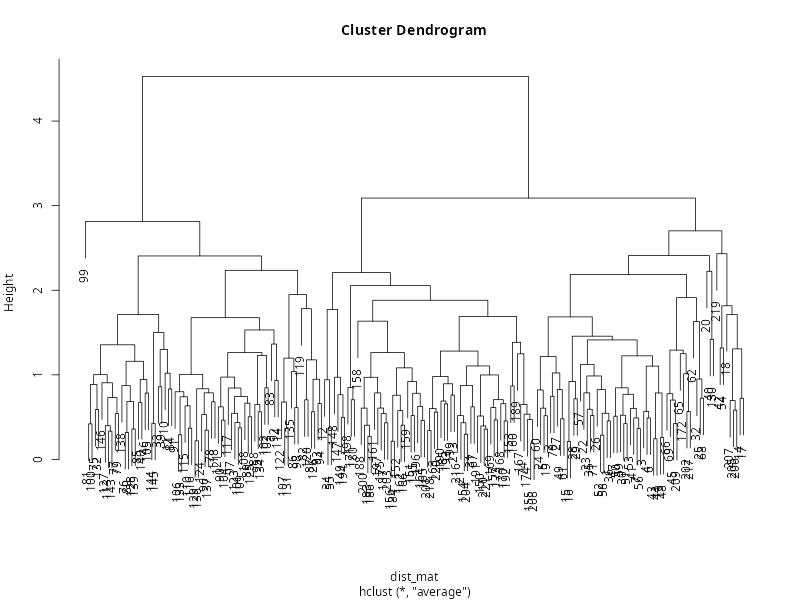

In [10]:
hclust_avg <- hclust(dist_mat, method = 'average')
plot(hclust_avg)

Se observa cómo se construye el dendrograma y cómo cada punto de datos se fusiona finalmente en un único conglomerado con la altura (distancia) mostrada en el eje y.

A continuación, puede cortar el dendrograma para crear el número deseado de conglomerados. Como en este caso ya se sabe que sólo puede haber tres tipos de trigo, se elegirá que el número de conglomerados sea **k = 3**, o como se puede ver en el dendrograma **h = 3** obtendrá tres conglomerados.    

Se utiliza la función `cutree()` de R para cortar el árbol con `hclust_avg` como un parámetro y el otro parámetro como *h = 3* o *k = 3*.    

A continuación se procede a desarrollar el método del codo para determinar el número óptimo de clusters (K) en el conjunto de datos iris.

In [11]:
cut_avg <- cutree(hclust_avg, k = 3)

Finalmente, si desea ver visualmente los clusters en el dendrograma, es posible utilizar la función `abline()` de R para dibujar la línea de corte y superponer compartimentos rectangulares para cada cluster en el árbol con la función `rect.hclust()` como se muestra en el siguiente código:

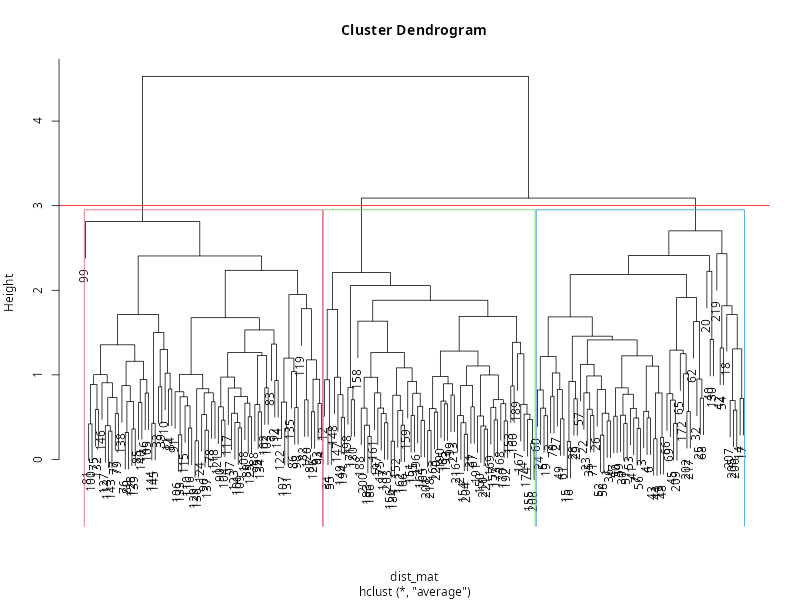

In [12]:
plot(hclust_avg)
rect.hclust(hclust_avg , k = 3, border = 2:6)
abline(h = 3, col = 'red')

Ahora se puede ver los tres grupos encerrados en tres cajas de colores diferentes.    

También se puede utilizar la función `color_branches()` de la biblioteca *dendextend* para visualizar el árbol con ramas de diferentes colores.

Loading required namespace: colorspace


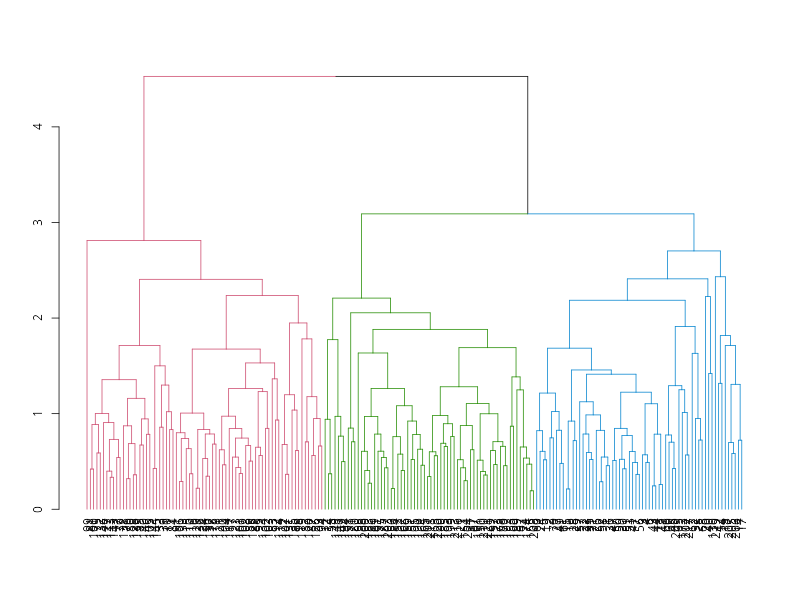

In [13]:
suppressPackageStartupMessages(library(dendextend))
avg_dend_obj <- as.dendrogram(hclust_avg)
avg_col_dend <- color_branches(avg_dend_obj, h = 3)
plot(avg_col_dend)

Ahora se anexan los resultados de los conglomerados obtenidos de nuevo en el marco de datos original bajo el nombre de columna cluster con `mutate()`, del paquete *dplyr* y se contará el número de observaciones que se asignaron a cada conglomerado con la función `count()`.

In [15]:
suppressPackageStartupMessages(library(dplyr))
seeds_df_cl <- mutate(seeds_df_clean, cluster = cut_avg)
count(seeds_df_cl,cluster)

  cluster  n
1       1 63
2       2 72
3       3 64

Ahora es posible ver cuántas observaciones se asignaron en cada agrupación. 

Es habitual evaluar la tendencia entre dos características basándose en la agrupación que se ha realizado para extraer información más útil de los datos agrupados. 

Seguidamente, se puede analizar la tendencia entre el `perimeter` y el `cluster-wise` con la ayuda del paquete `ggplot2`.

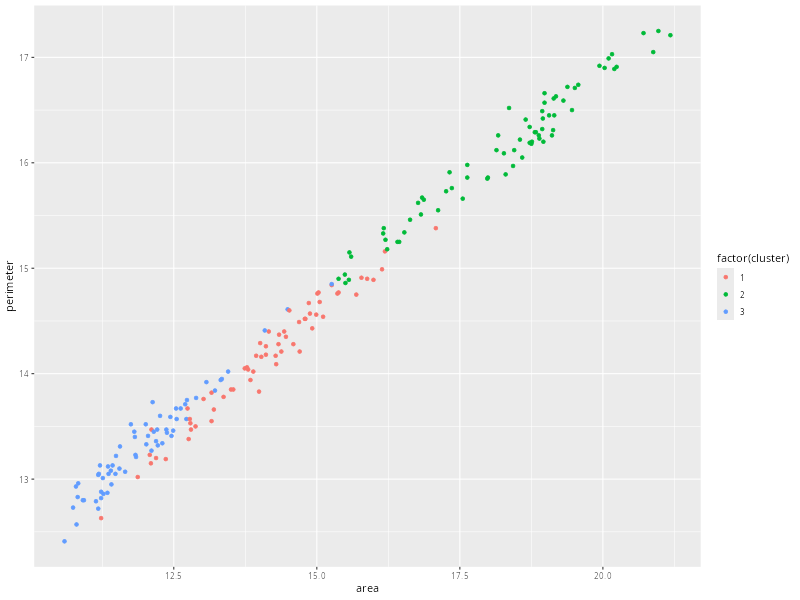

In [16]:
suppressPackageStartupMessages(library(ggplot2))
ggplot(seeds_df_cl, aes(x=area, y = perimeter, color = factor(cluster))) + geom_point()

Dado que ya se dispone de las etiquetas verdaderas para este conjunto de datos, también se puede considerar la posibilidad de realizar una comprobación cruzada de los resultados de la agrupación utilizando la función `table()`.

In [17]:
table(seeds_df_cl$cluster,seeds_label)

   seeds_label
     1  2  3
  1 54  1  8
  2  5 67  0
  3  7  0 57

Si echamos un vistazo a la tabla que se ha generado, se ve claramente tres grupos con 54 elementos o más.    
En general, puede decirse que los clústers representan adecuadamente los distintos tipos de semillas porque originalmente se partía de 70 observaciones para cada variedad de trigo.    
Los grupos más grandes representan la correspondencia entre las agrupaciones y los tipos reales.